In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV ke dataframe
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# Buat database SQLite di memory
conn = sqlite3.connect('superstore.db')

# Simpan dataframe ke tabel SQL
df.to_sql('orders', conn, if_exists='replace', index=False)

print("✅ Database berhasil dibuat!")
print(f"Total rows: {pd.read_sql('SELECT COUNT(*) as total FROM orders', conn).iloc[0,0]}")

✅ Database berhasil dibuat!
Total rows: 9994


In [2]:
query1 = """
SELECT 
    Category,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND(SUM(Profit)/SUM(Sales)*100, 2) AS Profit_Margin_Pct
FROM orders
GROUP BY Category
ORDER BY Total_Sales DESC
"""

df_q1 = pd.read_sql(query1, conn)
print("=== Total Penjualan per Kategori ===")
print(df_q1.to_string(index=False))

=== Total Penjualan per Kategori ===
       Category  Total_Sales  Total_Profit  Profit_Margin_Pct
     Technology    836154.03     145454.95              17.40
      Furniture    741999.80      18451.27               2.49
Office Supplies    719047.03     122490.80              17.04


In [3]:
query2 = """
SELECT 
    [Product Name],
    Category,
    [Sub-Category],
    ROUND(SUM(Sales), 2) AS Total_Sales,
    SUM(Quantity) AS Total_Qty
FROM orders
GROUP BY [Product Name], Category, [Sub-Category]
ORDER BY Total_Sales DESC
LIMIT 10
"""

df_q2 = pd.read_sql(query2, conn)
print("=== Top 10 Produk Terlaris ===")
print(df_q2.to_string(index=False))

=== Top 10 Produk Terlaris ===
                                                               Product Name        Category Sub-Category  Total_Sales  Total_Qty
                                      Canon imageCLASS 2200 Advanced Copier      Technology      Copiers     61599.82         20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind Office Supplies      Binders     27453.38         31
                      Cisco TelePresence System EX90 Videoconferencing Unit      Technology     Machines     22638.48          6
                               HON 5400 Series Task Chairs for Big and Tall       Furniture       Chairs     21870.58         39
                                 GBC DocuBind TL300 Electric Binding System Office Supplies      Binders     19823.48         37
                           GBC Ibimaster 500 Manual ProClick Binding System Office Supplies      Binders     19024.50         48
                                       Hewlett Packard LaserJet 33

In [4]:
query3 = """
SELECT 
    [Sub-Category],
    COUNT(DISTINCT [Order ID]) AS Jumlah_Order,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM orders
WHERE Profit < 0
GROUP BY [Sub-Category]
ORDER BY Total_Profit ASC
LIMIT 10
"""

df_q3 = pd.read_sql(query3, conn)
print("=== Sub-Kategori dengan Profit Negatif ===")
print(df_q3.to_string(index=False))

=== Sub-Kategori dengan Profit Negatif ===
Sub-Category  Jumlah_Order  Total_Sales  Total_Profit
     Binders           526     36140.61     -38510.50
      Tables           195    104978.55     -32412.15
    Machines            41     72456.25     -30118.67
   Bookcases           107     48072.74     -12152.21
      Chairs           226     91988.46      -9880.84
  Appliances            65      3382.53      -8629.64
      Phones           126     35797.84      -7530.62
 Furnishings           156     12845.84      -6490.91
     Storage           152     37869.07      -6426.30
    Supplies            33     14067.18      -3015.62


In [5]:
query4 = """
SELECT 
    Region,
    Year,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    COUNT(DISTINCT [Customer ID]) AS Jumlah_Customer
FROM orders
GROUP BY Region, Year
ORDER BY Region, Year
"""

df_q4 = pd.read_sql(query4, conn)
print("=== Penjualan per Region per Tahun ===")
print(df_q4.to_string(index=False))

=== Penjualan per Region per Tahun ===
 Region  Year  Total_Sales  Jumlah_Customer
Central  2014    103838.16              204
Central  2015    102874.22              201
Central  2016    147429.38              261
Central  2017    147098.13              325
   East  2014    128680.46              228
   East  2015    156332.06              246
   East  2016    180685.82              303
   East  2017    213082.90              354
  South  2014    103845.84              156
  South  2015     71359.98              155
  South  2016     93610.22              186
  South  2017    122905.86              223
   West  2014    147883.03              269
   West  2015    139966.25              276
   West  2016    187480.18              329
   West  2017    250128.37              397


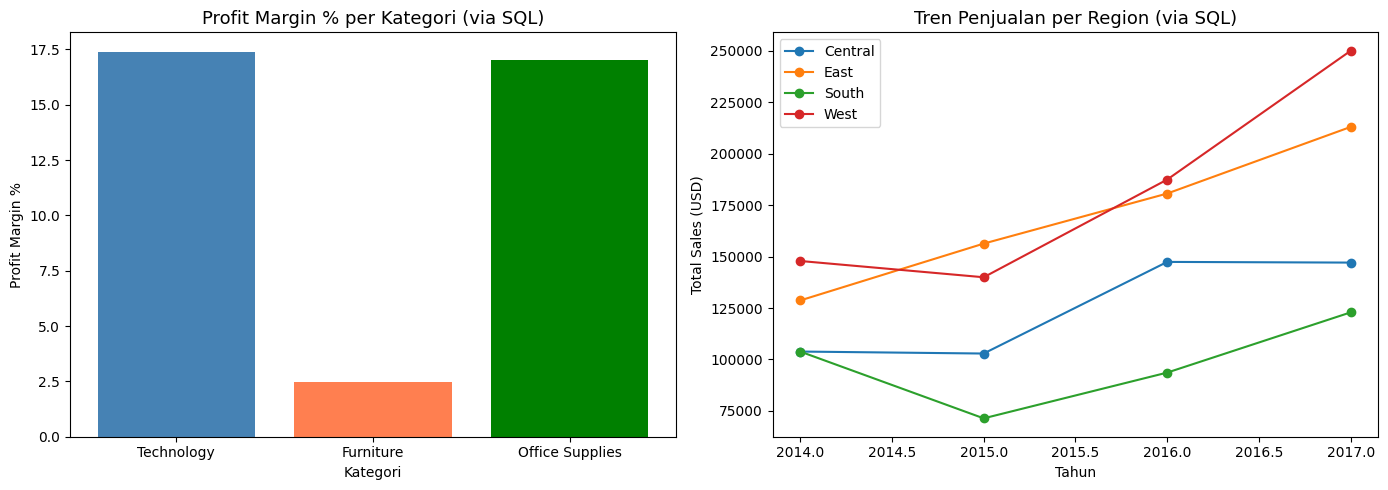

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Profit Margin per Kategori
axes[0].bar(df_q1['Category'], df_q1['Profit_Margin_Pct'], color=['steelblue','coral','green'])
axes[0].set_title('Profit Margin % per Kategori (via SQL)', fontsize=13)
axes[0].set_ylabel('Profit Margin %')
axes[0].set_xlabel('Kategori')

# Chart 2 - Penjualan per Region
for region in df_q4['Region'].unique():
    data = df_q4[df_q4['Region'] == region]
    axes[1].plot(data['Year'], data['Total_Sales'], marker='o', label=region)
axes[1].set_title('Tren Penjualan per Region (via SQL)', fontsize=13)
axes[1].set_ylabel('Total Sales (USD)')
axes[1].set_xlabel('Tahun')
axes[1].legend()

plt.tight_layout()
plt.show()